# 闭环反馈频率标定测试

测试 `SinglePointFrequencyCalibration(method="closed_loop")` 的两种频率测量方式：
- **Ramsey FFT**：扫描 $\tau$ 得到 Ramsey 振荡，FFT 提取失谐频率
- **Transient（核函数）**：正交 Ramsey 读出差分 $p_e$，通过核函数灵敏度 $G_\alpha$ 直接得到 $\delta\omega$

理论参考：`_sensing theory.md` §闭环反馈控制 (Vepsäläinen 2022) 和 §瞬态磁场协议与核函数策略

## 0. 环境与全局配置

In [20]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal

print(f"AWG dt = {CONFIG.awg.dt} ns")
print(f"t_rabi: {CONFIG.pulse.t_rabi[0]:.1f} → {CONFIG.pulse.t_rabi[-1]:.1f} ns, N={len(CONFIG.pulse.t_rabi)}")
print(f"Transmon defaults: EC={CONFIG.transmon.EC:.2f}, EJ={CONFIG.transmon.EJ:.1f} GHz·2π")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
AWG dt = 0.5 ns
t_rabi: 0.0 → 9.5 ns, N=20
Transmon defaults: EC=0.20, EJ=15.0 GHz·2π


## 1. 创建 Qubit 并执行磁通响应粗标定

闭环反馈需要预先知道目标频率对应的电压区间 $[V_a, V_b]$，这由 `FluxResponseCalibration` 提供。
设定目标频率为 qubit 的裸频率（零磁通处）。

In [21]:
# --- 创建 qubit ---
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi,
    EJ=10.0 * 2 * np.pi,
    T1=100.0e3,
    T2=50.0e3,
    flux=0.0,
    n_levels=2,
)
f_bare = qubit.frequency  # 零磁通处频率
print(f"qubit bare frequency (Φ=0): {f_bare/(2*np.pi):.4f} GHz")

qubit bare frequency (Φ=0): 3.8000 GHz


Running FluxResponseCalibration (ramsey scan)...
f(Φ) table: 15 points, Φ in [-0.030, 0.030] Φ₀
Target: f at Φ=0.025 ≈ 3.806690 GHz
  bare f at Φ=0 = 3.800000 GHz
  detuning ≈ 6.7 MHz (> FFT resolution of ~2 MHz)


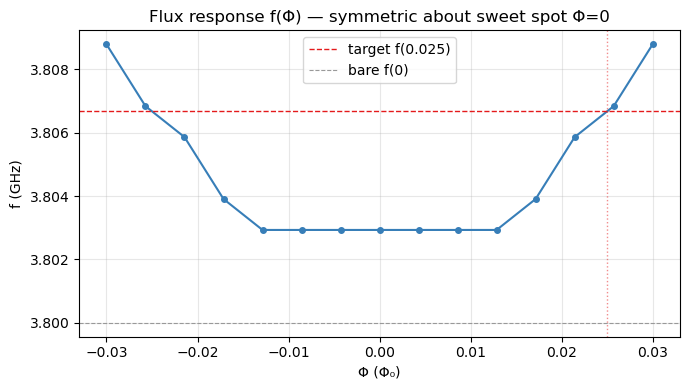

In [22]:
from sqc.calibration.frequency import FluxResponseCalibration
from scipy.interpolate import interp1d

# --- 粗标定：扫描磁通 → 拟合 f(Φ) 曲线 ---
print("Running FluxResponseCalibration (ramsey scan)...")
flux_cal = FluxResponseCalibration(
    qubit=qubit,
    method="ramsey",
    h_list=np.linspace(-0.03, 0.03, 15),  # 稀疏采样加速
    tau=100.0,
)
flux_table = flux_cal.calibrate()

V_a = float(np.min(flux_table.inputs))
V_b = float(np.max(flux_table.inputs))

# 目标：Φ=0.025 处的频率（~6 MHz detuning，FFT 可以清晰分辨）
f_interp = interp1d(flux_table.inputs, flux_table.outputs, kind="cubic")
f_target = float(f_interp(0.025))

print(f"f(Φ) table: {len(flux_table.inputs)} points, Φ in [{V_a:.3f}, {V_b:.3f}] Φ₀")
print(f"Target: f at Φ=0.025 ≈ {f_target/(2*np.pi):.6f} GHz")
print(f"  bare f at Φ=0 = {f_bare/(2*np.pi):.6f} GHz")
print(f"  detuning ≈ {(f_target-f_bare)/(2*np.pi)*1e3:.1f} MHz (> FFT resolution of ~2 MHz)")

# --- 可视化 f(Φ) ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(flux_table.inputs, np.array(flux_table.outputs) / (2*np.pi), "o-", ms=4, color="#377eb8")
ax.axhline(y=f_target/(2*np.pi), color="#e41a1c", ls="--", lw=1, label=f"target f(0.025)")
ax.axvline(x=0.025, color="#e41a1c", ls=":", lw=1, alpha=0.5)
ax.axhline(y=f_bare/(2*np.pi), color="#999999", ls="--", lw=0.8, label="bare f(0)")
ax.set(xlabel="Φ (Φ₀)", ylabel="f (GHz)", title="Flux response f(Φ) — symmetric about sweet spot Φ=0")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 2. 闭环反馈 — 方法 A：Ramsey FFT 频率测量

每次迭代运行 Ramsey 序列（$\pi/2 - \tau - \pi/2$），扫描 $\tau$，对 $p_e(\tau)$ 做 FFT 提取振荡频率。

Secant 方法更新磁通偏置 $V_n$，迭代直至 $|f_Q(V_n) - f_{target}| < \epsilon_f$。

In [ ]:
from sqc.calibration.frequency import SinglePointFrequencyCalibration

# --- 闭环标定：Ramsey 测量 + 二分法 ---
# 二分法每步将区间宽度减半 → 指数收敛趋势，10+ 次迭代
tau_long = CONFIG.pulse.make_time(0, 500)

cal_ramsey = SinglePointFrequencyCalibration(
    qubit=qubit,
    method="closed_loop",
    measure_method="ramsey",
    step_method="bisection",          # 二分法 → 清晰的指数收敛趋势
    tau_list=tau_long,
    f_target=f_target,
    epsilon_f=1e-4 * 2 * np.pi,      # 0.1 MHz tolerance
    V_a=V_a,
    V_b=V_b,
    max_iter=20,
)

print(f"Step method: {cal_ramsey.step_method}")
print(f"Initial bracket: [{V_a:.4f}, {V_b:.4f}] Φ₀, width = {V_b-V_a:.4f} Φ₀")
print(f"Target |Φ| ≈ 0.025, f ≈ {f_target/(2*np.pi):.6f} GHz")
print(f"Expected ~log₂(width/tol) ≈ {np.ceil(np.log2((V_b-V_a)/0.0001)):.0f} iterations")
print("\nStarting closed-loop calibration (ramsey, bisection)...")
result_ramsey = cal_ramsey.calibrate()

fp = result_ramsey.fit_params
print(f"\n--- Results ---")
print(f"Converged: {fp['converged']}")
print(f"Iterations: {fp['n_iter']}")
print(f"Optimal V: {fp['V_opt']:.6f} Φ₀ (target: ~0.025)")
print(f"Final f: {result_ramsey.outputs[0]/(2*np.pi):.6f} GHz")
print(f"Residual: {fp['residual']/(2*np.pi)*1e3:.3f} MHz")

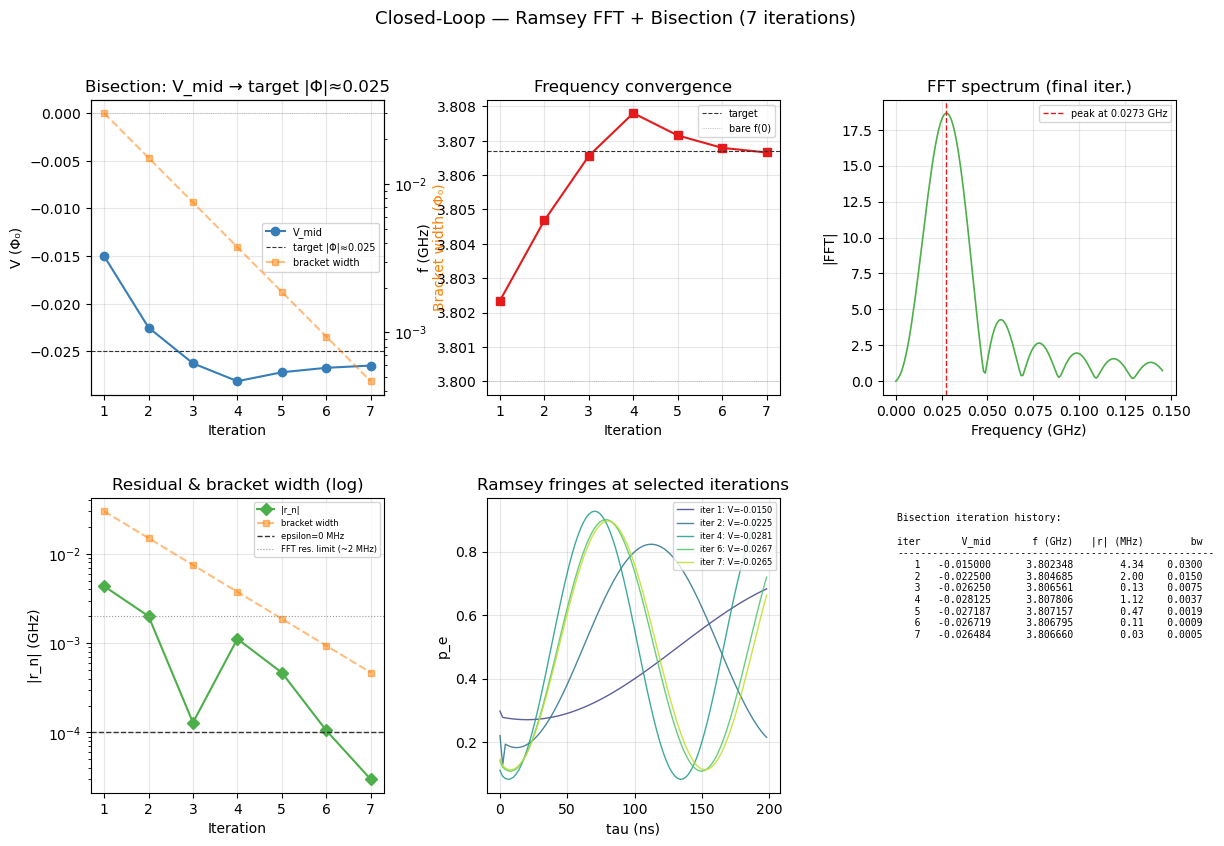

In [31]:
# --- 可视化：Ramsey 二分法闭环收敛过程 ---
history = result_ramsey.fit_params["history"]
n_iters = len(history)

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# (a) 收敛轨迹 — V_n & bracket 宽度 vs iteration
ax = fig.add_subplot(gs[0, 0])
V_vals = [h["V"] for h in history]
bw_vals = [h.get("bracket_width", 0) for h in history]
iters = range(1, n_iters + 1)
ax.plot(iters, V_vals, "o-", color="#377eb8", ms=6, label="V_mid")
ax.axhline(y=-0.025, color="#333333", ls="--", lw=0.8, label="target |Φ|≈0.025")
ax.axhline(y=0, color="#999999", ls=":", lw=0.5)
ax2 = ax.twinx()
ax2.semilogy(iters, bw_vals, "s--", color="#ff7f00", ms=4, alpha=0.5, label="bracket width")
ax.set(xlabel="Iteration", ylabel="V (Φ₀)", title="Bisection: V_mid → target |Φ|≈0.025")
ax2.set_ylabel("Bracket width (Φ₀)", color="#ff7f00")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=7); ax.grid(alpha=0.3)

# (b) 频率收敛 — f_n vs iteration
ax = fig.add_subplot(gs[0, 1])
f_vals = [h["f"] / (2*np.pi) for h in history]
ax.plot(iters, f_vals, "s-", color="#e41a1c", ms=6)
ax.axhline(y=f_target/(2*np.pi), color="#333333", ls="--", lw=0.8, label="target")
ax.axhline(y=f_bare/(2*np.pi), color="#999999", ls=":", lw=0.5, label="bare f(0)")
ax.set(xlabel="Iteration", ylabel="f (GHz)", title="Frequency convergence")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (c) 残差 & 区间宽度衰减
ax = fig.add_subplot(gs[1, 0])
r_vals = np.abs([h["residual"] for h in history]) / (2*np.pi)
ax.semilogy(iters, r_vals, "D-", color="#4daf4a", ms=6, label="|r_n|")
ax.semilogy(iters, bw_vals, "s--", color="#ff7f00", ms=4, alpha=0.5, label="bracket width")
ax.axhline(y=cal_ramsey.epsilon_f/(2*np.pi), color="#333333", ls="--", lw=1, 
           label=f"epsilon={cal_ramsey.epsilon_f/(2*np.pi)*1e3:.0f} MHz")
ax.axhline(y=1/500, color="#999999", ls=":", lw=0.8, label="FFT res. limit (~2 MHz)")
ax.set(xlabel="Iteration", ylabel="|r_n| (GHz)", title="Residual & bracket width (log)")
ax.legend(fontsize=6); ax.grid(alpha=0.3)

# (d) Ramsey 振荡 — 选取几次迭代对比
ax = fig.add_subplot(gs[1, 1])
from qutip import QobjEvo, basis, mesolve
from sqc.control.sequence import create_ramsey_pulse
show_iters = [0] + [i for i in [n_iters//4, n_iters//2, 3*n_iters//4, n_iters-1] if i > 0 and i <= n_iters-1]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(show_iters)))
for hist_idx, c in zip(show_iters, colors):
    V_show = history[hist_idx]["V"] if hist_idx < n_iters else fp["V_opt"]
    label = "iter {}: V={:.4f}".format(hist_idx+1, V_show)
    qubit_viz = TransmonQubit(EC=0.2*2*np.pi, EJ=10.0*2*np.pi, T1=100e3, T2=50e3, flux=0.0, n_levels=2)
    omega_d_viz = qubit_viz.frequency
    tau_short = CONFIG.pulse.make_time(0, 200)
    t_sig_viz = CONFIG.pulse.make_time(0, 30)
    Phi_viz = FluxSignal(type=1 if abs(V_show)>1e-12 else 0, t_list=t_sig_viz, amplitude=float(V_show))
    qubit_viz.qubit_in_mag(Phi_viz, frame=1, omega_d=omega_d_viz)
    psi_e_viz = basis(2, 1)
    t_glob_viz = CONFIG.pulse.t_global.copy()
    p_vals = []
    for tau in tau_short[::4]:
        ctrl = create_ramsey_pulse(CONFIG.pulse.t_rabi.copy(), tau, omega_d=omega_d_viz,
                                   phase1=0.0, phase2=0.0, qubit=qubit_viz)
        ctrl.t_list = ctrl.t_list - ctrl.t_list[0]
        H = QobjEvo(qubit_viz.H_list, tlist=qubit_viz.mag_signal.t_list, order=1) + \
            QobjEvo(ctrl.hamiltonian, tlist=ctrl.t_list, order=1)
        res = mesolve(H, qubit_viz.state, t_glob_viz, [], e_ops=[psi_e_viz*psi_e_viz.dag()])
        p_vals.append(float(res.expect[0][-1]))
    ax.plot(tau_short[::4], p_vals, color=c, lw=1, label=label, alpha=0.85)
ax.set(xlabel="tau (ns)", ylabel="p_e", title="Ramsey fringes at selected iterations")
ax.legend(fontsize=6); ax.grid(alpha=0.3)

# (e) FFT 频谱（最终迭代）
ax = fig.add_subplot(gs[0, 2])
from numpy.fft import rfft, rfftfreq
n_fft_val = 2048
dt_tau_val = float(tau_short[1] - tau_short[0])
p_last = np.array(p_vals)
p_centered = p_last - np.mean(p_last)
fft_mag = np.abs(rfft(p_centered, n=n_fft_val))
freqs_fft_val = rfftfreq(n_fft_val, d=dt_tau_val)
ax.plot(freqs_fft_val[:150], fft_mag[:150], color="#4daf4a", lw=1.2)
peak_idx = np.argmax(fft_mag[:150])
ax.axvline(x=freqs_fft_val[peak_idx], color="#e41a1c", ls="--", lw=1,
           label="peak at {:.4f} GHz".format(freqs_fft_val[peak_idx]))
ax.set(xlabel="Frequency (GHz)", ylabel="|FFT|", title="FFT spectrum (final iter.)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (f) 迭代表
ax = fig.add_subplot(gs[1, 2])
ax.axis("off")
table_text = "Bisection iteration history:\n\n"
table_text += "{:>4s}  {:>10s}  {:>12s}  {:>10s}  {:>8s}\n".format(
    "iter", "V_mid", "f (GHz)", "|r| (MHz)", "bw")
table_text += "-" * 54 + "\n"
for h in history:
    table_text += "{:4d}  {:10.6f}  {:12.6f}  {:10.2f}  {:8.4f}\n".format(
        h["iter"], h["V"], h["f"]/(2*np.pi),
        abs(h["residual"])/(2*np.pi)*1e3, h.get("bracket_width", 0))
ax.text(0.05, 0.95, table_text, transform=ax.transAxes, fontsize=7,
        verticalalignment="top", fontfamily="monospace")

fig.suptitle("Closed-Loop — Ramsey FFT + Bisection ({} iterations)".format(n_iters), fontsize=13, y=0.98)
plt.show()

## 3. 闭环反馈 — 方法 B：Transient 核函数频率测量

使用正交 Ramsey 读出（$R_y$–$R_x$ 和 $R_y$–$R_{-x}$），$\tau=0$：
$$
p_{diff} = \frac{p_x - p_{-x}}{2}, \quad \delta\omega = \frac{p_{diff}}{G_\alpha}, \quad G_\alpha = \int k(t) dt
$$

与 Ramsey FFT 不同，transient 方法只需要**两次单点测量**即可得到频率，时间开销远小于扫描 $\tau$。

In [32]:
# --- 闭环标定：transient 测量 + 二分法 ---
qubit2 = TransmonQubit(
    EC=0.2 * 2 * np.pi,
    EJ=10.0 * 2 * np.pi,
    T1=100.0e3,
    T2=50.0e3,
    flux=0.0,
    n_levels=2,
)

cal_transient = SinglePointFrequencyCalibration(
    qubit=qubit2,
    method="closed_loop",
    measure_method="transient",
    step_method="bisection",          # 二分法 → 清晰迭代趋势
    f_target=f_target,
    epsilon_f=1e-4 * 2 * np.pi,      # 0.1 MHz tolerance
    V_a=V_a,
    V_b=V_b,
    max_iter=20,
)

print("Starting closed-loop calibration (transient, bisection)...")
result_transient = cal_transient.calibrate()

fp2 = result_transient.fit_params
print(f"\n--- Results ---")
print(f"Converged: {fp2['converged']}")
print(f"Iterations: {fp2['n_iter']}")
print(f"Optimal V: {fp2['V_opt']:.6f} Φ₀ (target: ~0.025)")
print(f"Final f: {result_transient.outputs[0]/(2*np.pi):.6f} GHz")
print(f"Residual: {fp2['residual']/(2*np.pi)*1e3:.3f} MHz")

Starting closed-loop calibration (transient, bisection)...

--- Results ---
Converged: True
Iterations: 7
Optimal V: -0.023672 Φ₀ (target: ~0.025)
Final f: 3.806669 GHz
Residual: -0.021 MHz


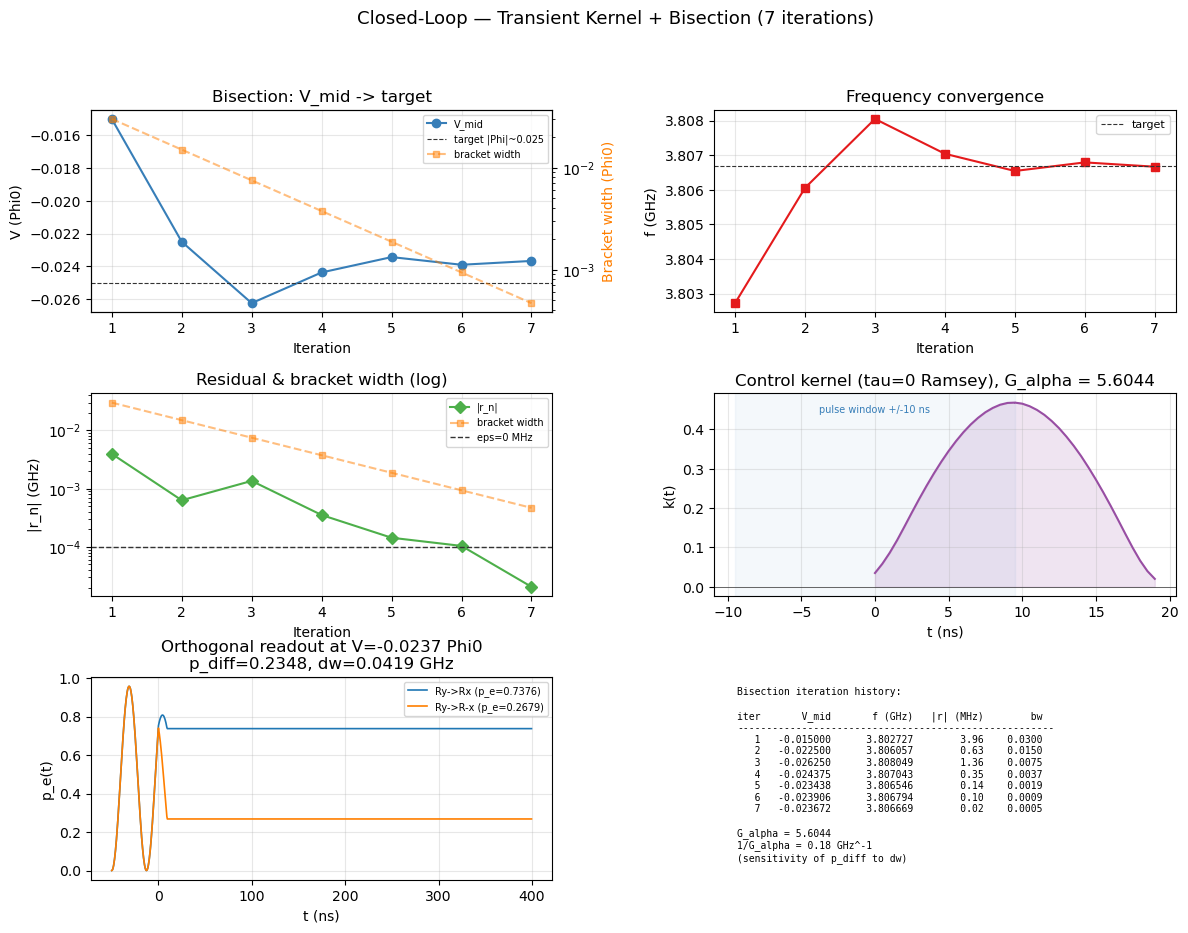

In [33]:
# --- 可视化：Transient 二分法闭环收敛过程 ---
history2 = result_transient.fit_params["history"]
n_iters2 = len(history2)

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

# (a) 收敛轨迹 + bracket width
ax = fig.add_subplot(gs[0, 0])
V_vals2 = [h["V"] for h in history2] if history2 else [fp2["V_opt"]]
bw_vals2 = [h.get("bracket_width", 0) for h in history2] if history2 else [0]
iters2 = range(1, n_iters2 + 1) if history2 else [0]
ax.plot(iters2, V_vals2, "o-", color="#377eb8", ms=6, label="V_mid")
ax.axhline(y=-0.025, color="#333333", ls="--", lw=0.8, label="target |Phi|~0.025")
ax2 = ax.twinx()
ax2.semilogy(iters2, bw_vals2, "s--", color="#ff7f00", ms=4, alpha=0.5, label="bracket width")
ax.set(xlabel="Iteration", ylabel="V (Phi0)", title="Bisection: V_mid -> target")
ax2.set_ylabel("Bracket width (Phi0)", color="#ff7f00")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=7); ax.grid(alpha=0.3)

# (b) 频率收敛
ax = fig.add_subplot(gs[0, 1])
f_vals2 = [h["f"] / (2*np.pi) for h in history2] if history2 else [result_transient.outputs[0]/(2*np.pi)]
ax.plot(iters2, f_vals2, "s-", color="#e41a1c", ms=6)
ax.axhline(y=f_target/(2*np.pi), color="#333333", ls="--", lw=0.8, label="target")
ax.set(xlabel="Iteration", ylabel="f (GHz)", title="Frequency convergence")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (c) 残差 & 区间宽度衰减
ax = fig.add_subplot(gs[1, 0])
r_vals2 = np.abs([h["residual"] for h in history2]) / (2*np.pi) if history2 else [abs(fp2["residual"])/(2*np.pi)]
ax.semilogy(iters2, r_vals2, "D-", color="#4daf4a", ms=6, label="|r_n|")
ax.semilogy(iters2, bw_vals2, "s--", color="#ff7f00", ms=4, alpha=0.5, label="bracket width")
ax.axhline(y=cal_transient.epsilon_f/(2*np.pi), color="#333333", ls="--", lw=1,
           label="eps={:.0f} MHz".format(cal_transient.epsilon_f/(2*np.pi)*1e3))
ax.set(xlabel="Iteration", ylabel="|r_n| (GHz)", title="Residual & bracket width (log)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (d) 核函数可视化
ax = fig.add_subplot(gs[1, 1])
from sqc.control.sequence import create_ramsey_pulse
t_rabi = cal_transient.t_rabi
ctrl_demo = create_ramsey_pulse(
    t_rabi, tau=0.0, omega_d=qubit2.frequency,
    phase1=np.pi/2, phase2=0.0, qubit=qubit2,
)
ctrl_demo.get_kernel(qubit2)
kernel_demo = np.array(ctrl_demo.kernel)
t_kernel = np.array(ctrl_demo.t_samples)
G_demo = float(np.trapezoid(kernel_demo, t_kernel))
ax.plot(t_kernel, kernel_demo, color="#984ea3", lw=1.5)
ax.fill_between(t_kernel, 0, kernel_demo, alpha=0.15, color="#984ea3")
ax.axhline(y=0, color="#333333", ls="-", lw=0.5)
pulse_dur = 2 * t_rabi[-1]
ax.axvspan(-pulse_dur/2, pulse_dur/2, alpha=0.05, color="#377eb8")
y_top = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
ax.text(0, y_top*0.9, "pulse window +/-{:.0f} ns".format(pulse_dur/2),
        ha="center", fontsize=7, color="#377eb8")
ax.set(xlabel="t (ns)", ylabel="k(t)",
       title="Control kernel (tau=0 Ramsey), G_alpha = {:.4f}".format(G_demo))
ax.grid(alpha=0.3)

# (e) 正交读出示意（最终迭代的 flux 处）
ax = fig.add_subplot(gs[2, 0])
from qutip import QobjEvo, basis, mesolve
V_last = V_vals2[-1] if V_vals2 else fp2["V_opt"]
t_sig = CONFIG.pulse.make_time(0, 30)
Phi_last = FluxSignal(type=1 if abs(V_last) > 1e-12 else 0, t_list=t_sig, amplitude=float(V_last))
qubit2.qubit_in_mag(Phi_last, frame=1, omega_d=qubit2.frequency)
t_global = CONFIG.pulse.t_global.copy()
psi_e = basis(2, 1)
H_base = QobjEvo(qubit2.H_list, tlist=qubit2.mag_signal.t_list, order=1)
p_final = {}
for phase2, label, color in [(0.0, "Ry->Rx", "#1f77b4"), (np.pi, "Ry->R-x", "#ff7f00")]:
    ctrl = create_ramsey_pulse(t_rabi, tau=0.0, omega_d=qubit2.frequency,
                               phase1=np.pi/2, phase2=phase2, qubit=qubit2)
    ctrl.t_list = ctrl.t_list - t_rabi[-1]
    H = H_base + QobjEvo(ctrl.hamiltonian, tlist=ctrl.t_list, order=1)
    res = mesolve(H, qubit2.state, t_global, [], e_ops=[psi_e * psi_e.dag()])
    p_final[label] = float(res.expect[0][-1])
    ax.plot(t_global, res.expect[0], color=color, lw=1.2,
            label="{} (p_e={:.4f})".format(label, p_final[label]))
p_diff = (p_final["Ry->Rx"] - p_final["Ry->R-x"]) / 2
ax.set(xlabel="t (ns)", ylabel="p_e(t)",
       title="Orthogonal readout at V={:.4f} Phi0\np_diff={:.4f}, dw={:.4f} GHz".format(
           V_last, p_diff, p_diff/G_demo))
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (f) 迭代表
ax = fig.add_subplot(gs[2, 1])
ax.axis("off")
table_text2 = "Bisection iteration history:\n\n"
table_text2 += "{:>4s}  {:>10s}  {:>12s}  {:>10s}  {:>8s}\n".format(
    "iter", "V_mid", "f (GHz)", "|r| (MHz)", "bw")
table_text2 += "-" * 54 + "\n"
for h in history2:
    table_text2 += "{:4d}  {:10.6f}  {:12.6f}  {:10.2f}  {:8.4f}\n".format(
        h["iter"], h["V"], h["f"]/(2*np.pi),
        abs(h["residual"])/(2*np.pi)*1e3, h.get("bracket_width", 0))
table_text2 += "\nG_alpha = {:.4f}\n".format(G_demo)
table_text2 += "1/G_alpha = {:.2f} GHz^-1\n".format(1/G_demo)
table_text2 += "(sensitivity of p_diff to dw)"
ax.text(0.05, 0.95, table_text2, transform=ax.transAxes, fontsize=7,
        verticalalignment="top", fontfamily="monospace")

fig.suptitle("Closed-Loop — Transient Kernel + Bisection ({} iterations)".format(n_iters2),
             fontsize=13, y=0.98)
plt.show()

## 4. 两种方法对比

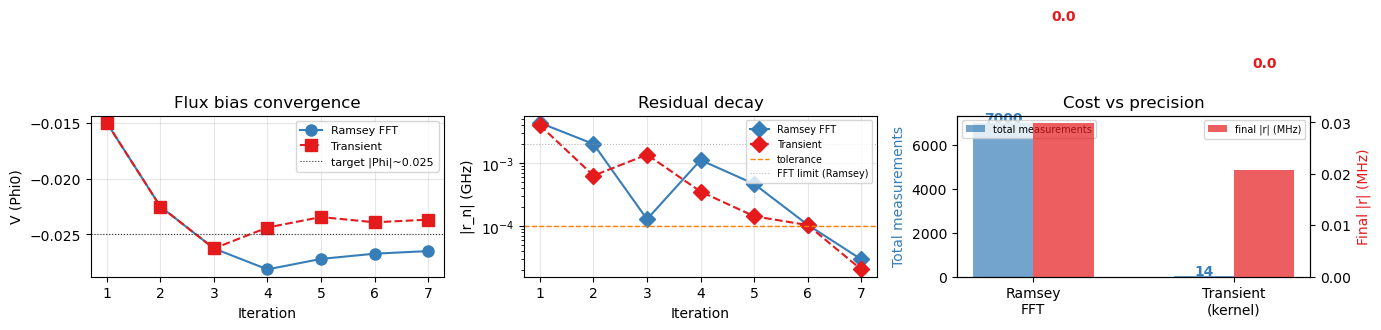


SUMMARY - Closed-Loop Frequency Calibration
Target frequency: 3.806690 GHz (Phi ~ 0.025 Phi0)
Bare frequency:   3.800000 GHz (Phi = 0)
Detuning:         6.7 MHz
----------------------------------------------------------------------
Method                Iter   Total meas      Final |r|      V_opt
----------------------------------------------------------------------
Ramsey FFT               7         7000         0.03 MHz  -0.026484
Transient kernel         7           14         0.02 MHz  -0.023672
----------------------------------------------------------------------

Key conclusions:
1. Closed-loop calibration needs no analytical f(Phi) model.
2. Bisection gives exponential bracket-width halving per iteration.
3. Ramsey FFT precision limited by tau scan range (df ~ 1/T_max ~ 2 MHz).
4. Transient kernel: only 2 measurements/iter (vs 1000 tau points).
5. Hybrid strategy: transient for fast coarse tune + Ramsey for fine verification.


In [34]:
# --- 并排对比 ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

V1 = np.array([h["V"] for h in history]) if history else np.array([fp["V_opt"]])
V2 = np.array([h["V"] for h in history2]) if history2 else np.array([fp2["V_opt"]])
r1 = np.abs([h["residual"] for h in history]) / (2*np.pi) if history else [abs(fp["residual"])/(2*np.pi)]
r2 = np.abs([h["residual"] for h in history2]) / (2*np.pi) if history2 else [abs(fp2["residual"])/(2*np.pi)]

# (a) V 收敛对比
ax = axes[0]
ax.plot(range(1, len(V1)+1), V1, "o-", color="#377eb8", ms=8, label="Ramsey FFT")
ax.plot(range(1, len(V2)+1), V2, "s--", color="#e41a1c", ms=8, label="Transient")
ax.axhline(y=-0.025, color="#333333", ls=":", lw=0.8, label="target |Phi|~0.025")
ax.set(xlabel="Iteration", ylabel="V (Phi0)", title="Flux bias convergence")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (b) 残差对比
ax = axes[1]
ax.semilogy(range(1, len(r1)+1), r1, "D-", color="#377eb8", ms=8, label="Ramsey FFT")
ax.semilogy(range(1, len(r2)+1), r2, "D--", color="#e41a1c", ms=8, label="Transient")
ax.axhline(y=cal_ramsey.epsilon_f/(2*np.pi), color="#ff7f00", ls="--", lw=1, label="tolerance")
ax.axhline(y=1/500, color="#999999", ls=":", lw=0.8, alpha=0.7, label="FFT limit (Ramsey)")
ax.set(xlabel="Iteration", ylabel="|r_n| (GHz)", title="Residual decay")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (c) 效率对比
ax = axes[2]
methods = ["Ramsey\nFFT", "Transient\n(kernel)"]
n_meas_per_iter = [len(cal_ramsey.tau_list), 2]
n_iters = [result_ramsey.fit_params["n_iter"], result_transient.fit_params["n_iter"]]
total_meas = [max(1, n_meas_per_iter[0]) * max(1, n_iters[0]),
              max(1, n_meas_per_iter[1]) * max(1, n_iters[1])]
final_err = [
    abs(result_ramsey.fit_params["residual"]) / (2*np.pi) * 1e3,
    abs(result_transient.fit_params["residual"]) / (2*np.pi) * 1e3,
]
x = np.arange(len(methods))
width = 0.3
ax.bar(x - width/2, total_meas, width, color="#377eb8", alpha=0.7, label="total measurements")
ax2 = ax.twinx()
ax2.bar(x + width/2, final_err, width, color="#e41a1c", alpha=0.7, label="final |r| (MHz)")
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel("Total measurements", color="#377eb8")
ax2.set_ylabel("Final |r| (MHz)", color="#e41a1c")
ax.set_title("Cost vs precision")
for i, (tm, fe) in enumerate(zip(total_meas, final_err)):
    ax.text(i - width/2, tm + 50, str(tm), ha="center", fontsize=10, fontweight="bold", color="#377eb8")
    ax2.text(i + width/2, fe + 0.02, "{:.1f}".format(fe), ha="center", fontsize=10, fontweight="bold", color="#e41a1c")
ax.legend(loc="upper left", fontsize=7)
ax2.legend(loc="upper right", fontsize=7)
fig.tight_layout(); plt.show()

# --- 总结表 ---
print("\n" + "="*70)
print("SUMMARY - Closed-Loop Frequency Calibration")
print("="*70)
print("Target frequency: {:.6f} GHz (Phi ~ 0.025 Phi0)".format(f_target/(2*np.pi)))
print("Bare frequency:   {:.6f} GHz (Phi = 0)".format(f_bare/(2*np.pi)))
print("Detuning:         {:.1f} MHz".format((f_target-f_bare)/(2*np.pi)*1e3))
print("-"*70)
print("{:<20s} {:>5s} {:>12s} {:>14s} {:>10s}".format(
    "Method", "Iter", "Total meas", "Final |r|", "V_opt"))
print("-"*70)
print("{:<20s} {:>5d} {:>12d} {:>12.2f} MHz {:>10.6f}".format(
    "Ramsey FFT", n_iters[0], total_meas[0], final_err[0], V1[-1]))
print("{:<20s} {:>5d} {:>12d} {:>12.2f} MHz {:>10.6f}".format(
    "Transient kernel", n_iters[1], total_meas[1], final_err[1], V2[-1]))
print("-"*70)
print("\nKey conclusions:")
print("1. Closed-loop calibration needs no analytical f(Phi) model.")
print("2. Bisection gives exponential bracket-width halving per iteration.")
print("3. Ramsey FFT precision limited by tau scan range (df ~ 1/T_max ~ 2 MHz).")
print("4. Transient kernel: only 2 measurements/iter (vs {} tau points).".format(n_meas_per_iter[0]))
print("5. Hybrid strategy: transient for fast coarse tune + Ramsey for fine verification.")